# Exp 1b: 도메인 피처 확장 + 공정 벤치마크

## 목표
1. **피처 12 → 25개**: 2홉 통계, 교호작용, 시간 버스트 등 추가 → AISO 성능 천장 탐색
2. **PSO(Dom) 비교**: 최적 피처셋에서 PSO도 동일 공간 탐색 → 알고리즘 기여 분리
3. **그래프 특화 baseline**: PageRank 가중 샘플링, 임베딩 기반 밀도 샘플링

## 기준선
AISO(Dom-12, N=12) mean=0.6041 ± 0.0250, 5/5 beats PSO(PCA)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'

print('데이터 로딩...')
feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1, 167)]
X_all = labeled[feat_cols].values.astype(float)
y_all = labeled["y"].values
ts_all = labeled["timestep"].values
N_NODES = len(labeled)
txid_to_idx = {txid: i for i, txid in enumerate(labeled["txId"].values)}

e_s = edge_df['txId1'].map(txid_to_idx)
e_d = edge_df['txId2'].map(txid_to_idx)
valid = e_s.notna() & e_d.notna()
s_arr = e_s[valid].astype(int).values
d_arr = e_d[valid].astype(int).values
mask  = (s_arr < N_NODES) & (d_arr < N_NODES)
ei_np2 = np.stack([s_arr[mask], d_arr[mask]])
# 방향 그래프: ei_np2[0]=src, ei_np2[1]=dst
src_arr, dst_arr = ei_np2[0], ei_np2[1]

SPLIT_T = 34
train_mask = ts_all <= SPLIT_T
test_mask  = ts_all >  SPLIT_T
train_illicit_idx = np.where(train_mask & (y_all == 1))[0]
train_licit_idx   = np.where(train_mask & (y_all == 0))[0]
N_LICIT = 10000; N_SEEN = 1000
X_scaled = StandardScaler().fit_transform(X_all)
print(f'로딩 완료: {N_NODES:,} 노드, illicit_train={len(train_illicit_idx):,}')

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


데이터 로딩...
로딩 완료: 46,564 노드, illicit_train=3,462


In [2]:
# ---- 25개의 도메인 피처 계산 ----
illicit_labels = y_all.astype(float)

# 양방향 엣지 (showdown 동일: src_bi = [src→dst] + [dst→src])
src_bi = np.concatenate([src_arr, dst_arr])
dst_bi = np.concatenate([dst_arr, src_arr])

# node_degree = total degree (showdown: bincount(ei_np[0]) on bidirectional)
node_degree = np.bincount(src_bi, minlength=N_NODES).astype(float)

# 1홉 illicit 이웃비율 (양방향)
illicit_neigh_sum = np.zeros(N_NODES)
np.add.at(illicit_neigh_sum, src_bi, illicit_labels[dst_bi])
illicit_neigh_ratio = illicit_neigh_sum / np.maximum(node_degree, 1)

# 2홉 illicit 비율 (양방향)
neigh2_illicit = np.zeros(N_NODES)
np.add.at(neigh2_illicit, src_bi, illicit_neigh_ratio[dst_bi])
neigh2_illicit /= np.maximum(node_degree, 1)

hub_fraud = node_degree * illicit_neigh_ratio

# 타임스텝
ts_rate_map = {t: y_all[ts_all==t].mean() for t in np.unique(ts_all)}
node_ts_illicit_rate = np.array([ts_rate_map[t] for t in ts_all])
ts_min, ts_max = ts_all.min(), ts_all.max()
ts_norm = (ts_all - ts_min) / max(ts_max - ts_min, 1)

# local/agg 피처
local_feat = X_scaled[:, 1:94]; agg_feat = X_scaled[:, 94:166]
local_mean = local_feat.mean(1); local_std = local_feat.std(1); local_max = local_feat.max(1)
local_min  = local_feat.min(1)
agg_mean   = agg_feat.mean(1);  agg_std  = agg_feat.std(1);  agg_max  = agg_feat.max(1)
agg_min    = agg_feat.min(1)

# ---- 기본 12개 (양방향 기준 — showdown 동일) ----
domain_raw_12 = np.stack([node_degree, illicit_neigh_ratio, neigh2_illicit,
    node_ts_illicit_rate, local_mean, local_std, local_max,
    agg_mean, agg_std, agg_max, ts_norm, hub_fraud], axis=1)

# ---- 확장 13개 (in/out-degree 등 directed 피처 추가) ----
out_degree = np.bincount(src_arr, minlength=N_NODES).astype(float)
in_degree  = np.bincount(dst_arr, minlength=N_NODES).astype(float)
in_out_ratio = in_degree / np.maximum(out_degree, 1)

neigh_degree_sum = np.zeros(N_NODES)
np.add.at(neigh_degree_sum, src_bi, node_degree[dst_bi])
neigh_degree_mean = neigh_degree_sum / np.maximum(node_degree, 1)

neigh2_hub = np.zeros(N_NODES)
np.add.at(neigh2_hub, src_bi, hub_fraud[dst_bi])
neigh2_hub /= np.maximum(node_degree, 1)

global_illicit_mean = y_all.mean()
ts_burst         = np.abs(node_ts_illicit_rate - global_illicit_mean)
degree_log       = np.log1p(node_degree)
degree_x_ts      = node_degree * node_ts_illicit_rate
illicit_x_neigh2 = illicit_neigh_ratio * neigh2_illicit
hub_x_ts         = hub_fraud * node_ts_illicit_rate
local_range      = local_max - local_min
agg_range        = agg_max - agg_min
local_agg_diff   = np.abs(local_mean - agg_mean)
illicit_isolation = illicit_neigh_ratio - neigh2_illicit

domain_raw_25 = np.concatenate([domain_raw_12, np.stack([
    neigh_degree_mean, neigh2_hub, ts_burst,
    degree_log, degree_x_ts, illicit_x_neigh2, hub_x_ts,
    local_range, agg_range, local_agg_diff,
    illicit_isolation, in_degree, in_out_ratio,
], axis=1)], axis=1)

from sklearn.preprocessing import MinMaxScaler
domain_norm_12 = MinMaxScaler().fit_transform(domain_raw_12)
domain_norm_25 = MinMaxScaler().fit_transform(domain_raw_25)
X_anom_12 = domain_norm_12[train_illicit_idx]
X_anom_25 = domain_norm_25[train_illicit_idx]

feat_names_25 = [
    'degree', 'illicit_neigh', 'neigh2_illicit', 'ts_illicit',
    'local_mean', 'local_std', 'local_max',
    'agg_mean', 'agg_std', 'agg_max', 'ts_norm', 'hub_fraud',
    'neigh_degree_mean', 'neigh2_hub', 'ts_burst',
    'degree_log', 'degree_x_ts', 'illicit_x_neigh2', 'hub_x_ts',
    'local_range', 'agg_range', 'local_agg_diff',
    'illicit_isolation', 'in_degree', 'in_out_ratio',
]
print(f'Dom-12: {X_anom_12.shape}, Dom-25: {X_anom_25.shape}')
print(f'  node_degree 양방향 확인: 예) node0={node_degree[0]:.1f}')


Dom-12: (3462, 12), Dom-25: (3462, 25)
  node_degree 양방향 확인: 예) node0=62.0


In [3]:
SEED = 42

# bidirectional edge_index (showdown 동일)
edge_index = torch.tensor(
    [np.concatenate([src_arr, dst_arr]),
     np.concatenate([dst_arr, src_arr])],
    dtype=torch.long
)
ei_np = edge_index.numpy()

# sel_n 고정 1회 (showdown: SEED=42)
sel_n = np.random.RandomState(SEED).choice(train_licit_idx, N_LICIT, replace=False)

_LOOKUP = np.full(N_NODES, -1, dtype=np.int32)

class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)

import copy

def evaluate_gnn(sel_pool_idx, label=''):
    """Exact showdown transductive protocol"""
    uniq_anom       = np.unique(sel_pool_idx)
    sel_anom_global = train_illicit_idx[uniq_anom]
    test_global     = np.where(test_mask)[0]

    sub_nodes = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
    n_sub = len(sub_nodes)

    _LOOKUP[:] = -1
    _LOOKUP[sub_nodes] = np.arange(n_sub)
    src_loc = _LOOKUP[ei_np[0]]
    dst_loc = _LOOKUP[ei_np[1]]
    ok = (src_loc >= 0) & (dst_loc >= 0)
    sub_ei = torch.tensor([src_loc[ok], dst_loc[ok]], dtype=torch.long).to(DEVICE)

    sub_X = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
    sub_y = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)

    train_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
    test_set  = set(test_global.tolist())
    tr_mask = torch.tensor([g in train_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    te_mask = torch.tensor([g in test_set  for g in sub_nodes], dtype=torch.bool).to(DEVICE)

    n0 = int((y_all[sub_nodes][tr_mask.cpu().numpy()] == 0).sum())
    n1 = int((y_all[sub_nodes][tr_mask.cpu().numpy()] == 1).sum())
    cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

    torch.manual_seed(SEED)
    model = GCN(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_loss, best_state, patience = float('inf'), None, 0
    for ep in range(200):
        model.train(); opt.zero_grad()
        out  = model(sub_X, sub_ei)
        loss = F.cross_entropy(out[tr_mask], sub_y[tr_mask], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss  = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience   = 0
        else:
            patience += 1
        if patience >= 20:
            break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(sub_X, sub_ei), dim=1)[:, 1].cpu().numpy()
    pred   = (prob >= 0.5).astype(int)
    te_cpu = te_mask.cpu().numpy()
    res = {
        'PR-AUC': average_precision_score(y_all[sub_nodes][te_cpu], prob[te_cpu]),
        'F1':     f1_score(y_all[sub_nodes][te_cpu], pred[te_cpu], zero_division=0),
        'AUC':    roc_auc_score(y_all[sub_nodes][te_cpu], prob[te_cpu]),
    }
    if label:
        print(f'  {label:<28} PR-AUC={res["PR-AUC"]:.4f}  F1={res["F1"]:.4f}')
    return res

# sanity check
SEEDS_VAL = [0, 7, 42, 77, 123]
print('evaluate_gnn 준비 완료 (showdown 트랜스덕티브 프로토콜)')
print(f'  sel_n 고정: {len(sel_n):,}개  |  edge_index 양방향: {edge_index.shape[1]:,}개')
print()
print('--- sanity check: AISO(Dom-12 N=12) SEED=42 ---')


evaluate_gnn 준비 완료 (showdown 트랜스덕티브 프로토콜)
  sel_n 고정: 10,000개  |  edge_index 양방향: 73,248개

--- sanity check: AISO(Dom-12 N=12) SEED=42 ---


In [4]:
GNN_N_AG = 20; GNN_N_IT = 80; GNN_ALPHA = 0.2; GNN_BETA = 0.08
GNN_M_LOW = -0.5; GNN_W_REPEL = 2.0
SEEDS_VAL = [0, 7, 42, 77, 123]
BASELINE_12 = 0.6041; BASELINE_STD = 0.0250

def _norm(X):
    mn, mx = X.min(0), X.max(0)
    return (X - mn) / np.where(mx - mn > 1e-8, mx - mn, 1.0)

def run_aiso(X_a, n, seed, n_types=None):
    rng = np.random.RandomState(seed)
    Xn = _norm(X_a); N_a, D = Xn.shape
    if n_types is None: n_types = D
    X = Xn[rng.choice(N_a, GNN_N_AG, replace=True)].copy().astype(float)
    W = rng.dirichlet(np.ones(n_types), GNN_N_AG)
    M = rng.uniform(GNN_M_LOW, GNN_W_REPEL, (n_types, n_types))
    visit = np.zeros(N_a); w_r = GNN_W_REPEL
    for t in range(GNN_N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X[i]-X[j])
                           for i in range(GNN_N_AG) for j in range(i+1, GNN_N_AG)])
            w_r = 1.0 + 3.0 * np.exp(-div / 0.12)
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(GNN_N_AG):
            ci = C[i].copy(); ci[i] = 0
            ta  = np.argsort(ci)[-3:]; tr2 = np.argsort(ci)[:3]
            Fv  = sum(ci[j]*(X[j]-X[i]) for j in ta)
            Fv += w_r * sum(ci[j]*(X[j]-X[i]) for j in tr2)
            Fv /= 6.0
            nn_idx = np.argmin(np.linalg.norm(Xn - np.clip(X[i]+GNN_ALPHA*Fv,0,1), axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            bja = ta[np.argmax(ci[ta])]
            W_new = (1-GNN_BETA)*W[i] + GNN_BETA*W[bja]; W_new /= W_new.sum()
            W[i] = W_new
    probs = visit + 1.0; probs /= probs.sum()
    return rng.choice(N_a, n, replace=True, p=probs)

print('AISO 함수 정의 완료')

AISO 함수 정의 완료


## Part 1: 피처 셋 그리드 탐색

| 셋 | 피처 수 | N_TYPES | 내용 |
|----|---------|---------|------|
| Dom-12 | 12 | 12 | 기존 기준선 |
| Dom-25 | 25 | 25 | 전체 확장 |
| Dom-25 N=12 | 25 | 12 | 피처 많되 타입은 12 유지 |
| Dom-18 | 18 | 18 | 중간 (기존 12 + 교호작용 6개) |
| Dom-Top12 | 12 | 12 | 25개 중 상관관계 낮은 12개 선택 |

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Dom-18: 기존 12 + 교호작용/확장 6개
feat_idx_18 = list(range(12)) + [14, 16, 17, 18, 21, 22]  # ts_burst, degree_x_ts, illicit_x_neigh2, hub_x_ts, local_agg_diff, illicit_isolation
X_anom_18 = MMS().fit_transform(domain_raw_25[:, feat_idx_18])[train_illicit_idx]

# Dom-Top12: 25개 중 상호 상관이 가장 낮은 12개 선택 (다양성 극대화)
corr_25 = np.corrcoef(X_anom_25.T)
# 탐욕적 선택: 이미 선택된 피처들과 평균 상관이 가장 낮은 피처를 순서대로 추가
selected = [0]  # degree부터 시작
for _ in range(11):
    best_feat, best_score = -1, np.inf
    for f in range(25):
        if f in selected: continue
        avg_corr = np.mean([abs(corr_25[f, s]) for s in selected])
        if avg_corr < best_score:
            best_score = avg_corr; best_feat = f
    selected.append(best_feat)
print(f'Top12 선택 피처: {[feat_names_25[i] for i in sorted(selected)]}')
X_anom_top12 = MMS().fit_transform(domain_raw_25[:, sorted(selected)])[train_illicit_idx]

feat_configs = [
    ('Dom-12  N=12', X_anom_12,    12),
    ('Dom-18  N=18', X_anom_18,    18),
    ('Dom-25  N=25', X_anom_25,    25),
    ('Dom-25  N=12', X_anom_25,    12),
    ('Dom-Top12 N=12', X_anom_top12, 12),
]

feat_results = {}
print(f'{"피처셋":<18} {"mean":>7} {"std":>7}  vs 기준')
print('-' * 50)
for label, X_a, n_t in feat_configs:
    scores = [evaluate_gnn(run_aiso(X_a, N_SEEN, sd, n_types=n_t))['PR-AUC']
              for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    feat_results[label] = (scores, m, s, X_a, n_t)
    flag = '★' if m > BASELINE_12 else ''
    print(f'  {label:<16} {m:.4f}  {s:.4f}  {m-BASELINE_12:+.4f} {flag}')
print()
print(f'  {"기존 Dom-12 N=12":<16} {BASELINE_12:.4f}  {BASELINE_STD:.4f}  (기준)')

Top12 선택 피처: ['degree', 'ts_illicit', 'local_mean', 'agg_mean', 'agg_max', 'ts_norm', 'neigh2_hub', 'ts_burst', 'illicit_x_neigh2', 'local_range', 'agg_range', 'illicit_isolation']
피처셋                   mean     std  vs 기준
--------------------------------------------------
  Dom-12  N=12     0.6041  0.0250  +0.0000 ★
  Dom-18  N=18     0.4836  0.0676  -0.1205 
  Dom-25  N=25     0.5354  0.0813  -0.0687 
  Dom-25  N=12     0.5530  0.0529  -0.0511 
  Dom-Top12 N=12   0.5572  0.0254  -0.0469 

  기존 Dom-12 N=12   0.6041  0.0250  (기준)


## Part 2: PSO(Dom) — 알고리즘 기여 분리

최적 피처셋에서 PSO도 동일 공간 탐색.
PSO 목적함수: 각 위치에서 k-NN 기반 이상치 밀도 (높을수록 좋음).
방문 빈도 기반 샘플링은 AISO와 동일 방식.

In [6]:
def run_pso(X_a, n, seed):
    rng = np.random.RandomState(seed)
    Xn = _norm(X_a); N_a, D = Xn.shape

    # 목적함수: 위치에서 가장 가까운 5개 이상치까지 평균 거리 (음수)
    def density_score(pos_idx):
        dists = np.linalg.norm(Xn - Xn[pos_idx], axis=1)
        dists[pos_idx] = np.inf
        return -np.sort(dists)[:5].mean()

    init_idx = rng.choice(N_a, GNN_N_AG, replace=True)
    X = Xn[init_idx].copy().astype(float)
    V = rng.randn(GNN_N_AG, D) * 0.02
    S = np.array([density_score(i) for i in init_idx])
    pb = X.copy(); ps = S.copy()
    best_i = np.argmax(S)
    gb = X[best_i].copy(); gs = S[best_i]

    visit = np.zeros(N_a)
    for i in init_idx: visit[i] += 1.0

    w_in = 0.729; c1 = 1.494; c2 = 1.494

    for t in range(GNN_N_IT):
        r1 = rng.rand(GNN_N_AG, D); r2 = rng.rand(GNN_N_AG, D)
        V = w_in*V + c1*r1*(pb-X) + c2*r2*(gb-X)
        X_new = np.clip(X + V, 0, 1)
        # 가장 가까운 이상치 노드로 스냅
        for i in range(GNN_N_AG):
            nn_idx = np.argmin(np.linalg.norm(Xn - X_new[i], axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            s_i = density_score(nn_idx)
            if s_i > ps[i]:
                pb[i] = X[i]; ps[i] = s_i
            if s_i > gs:
                gb = X[i].copy(); gs = s_i

    probs = visit + 1.0; probs /= probs.sum()
    return rng.choice(N_a, n, replace=True, p=probs)

# 기존 PSO(PCA) 기준선
BASELINE_PSO_PCA = 0.5621

# 최적 피처셋으로 PSO 실행
best_feat_label = max(feat_results, key=lambda k: feat_results[k][1])
_, best_m, _, X_best, n_t_best = feat_results[best_feat_label]
print(f'최적 피처셋: {best_feat_label}  mean={best_m:.4f}')
print()

pso_configs = [
    ('PSO(Dom-12)',    X_anom_12),
    ('PSO(Dom-25)',    X_anom_25),
    (f'PSO({best_feat_label.strip()})', X_best),
]

pso_results = {}
print(f'{"방법":<22} {"mean":>7} {"std":>7}  vs PSO(PCA) | vs AISO기준')
print('-' * 65)
for label, X_a in pso_configs:
    scores = [evaluate_gnn(run_pso(X_a, N_SEEN, sd))['PR-AUC'] for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    pso_results[label] = scores
    flag = '★' if m > BASELINE_12 else ''
    print(f'  {label:<20} {m:.4f}  {s:.4f}  {m-BASELINE_PSO_PCA:+.4f}     | {m-BASELINE_12:+.4f} {flag}')
print()
print(f'  {"PSO(PCA) 기존":<20} {BASELINE_PSO_PCA:.4f}  0.0732  (기준)')
print(f'  {"AISO(Dom-12)":<20} {BASELINE_12:.4f}  {BASELINE_STD:.4f}  (AISO 기준)')

최적 피처셋: Dom-12  N=12  mean=0.6041

방법                        mean     std  vs PSO(PCA) | vs AISO기준
-----------------------------------------------------------------
  PSO(Dom-12)          0.4810  0.0545  -0.0811     | -0.1231 
  PSO(Dom-25)          0.5279  0.0333  -0.0342     | -0.0762 
  PSO(Dom-12  N=12)    0.4810  0.0545  -0.0811     | -0.1231 

  PSO(PCA) 기존          0.5621  0.0732  (기준)
  AISO(Dom-12)         0.6041  0.0250  (AISO 기준)


## Part 3: 그래프 특화 Baseline

### PageRank 가중 샘플링
이상치 노드 서브그래프 내 근사 PageRank 계산 → 높은 PR 노드 위주 샘플링.
"중심적인" 이상치 노드가 GNN 학습에 더 유익하다는 가설.

### 임베딩 밀도 샘플링
GCN 인코더로 노드 임베딩 생성 → 임베딩 공간에서 이상치 클러스터 밀도 계산
→ 밀도 비례 샘플링 (희귀 패턴 보존).

In [9]:
# PageRank 기반 샘플링
def pagerank_sampling(n, seed, n_iter=30, damping=0.85):
    rng = np.random.RandomState(seed)
    anom_set = set(train_illicit_idx.tolist())
    anom_idx_map = {g: l for l, g in enumerate(train_illicit_idx)}
    N_a = len(train_illicit_idx)

    sub_src_list = []; sub_dst_list = []
    for s, d in zip(src_arr, dst_arr):
        if s in anom_set and d in anom_set:
            sub_src_list.append(anom_idx_map[s])
            sub_dst_list.append(anom_idx_map[d])

    pr = np.ones(N_a) / N_a
    out_deg = np.bincount(sub_src_list, minlength=N_a).astype(float)
    out_deg = np.maximum(out_deg, 1)
    for _ in range(n_iter):
        new_pr = np.ones(N_a) * (1 - damping) / N_a
        for s, d in zip(sub_src_list, sub_dst_list):
            new_pr[d] += damping * pr[s] / out_deg[s]
        pr = new_pr; pr /= pr.sum()

    probs = pr + 1e-6; probs /= probs.sum()
    return rng.choice(N_a, n, replace=True, p=probs)


# 임베딩 밀도 샘플링
def embedding_density_sampling(n, seed, hidden=32, n_iter=50):
    rng_np = np.random.RandomState(seed)
    torch.manual_seed(seed)

    licit_idx = rng_np.choice(train_licit_idx, 3000, replace=False)
    sub_idx = np.concatenate([licit_idx, train_illicit_idx])
    sub_map = {g: l for l, g in enumerate(sub_idx)}

    sub_s = []; sub_d = []
    for s, d in zip(src_arr, dst_arr):
        if s in sub_map and d in sub_map:
            sub_s.append(sub_map[s]); sub_d.append(sub_map[d])

    if not sub_s:
        return rng_np.choice(len(train_illicit_idx), n, replace=True)

    ei_sub = torch.tensor([sub_s, sub_d], dtype=torch.long).to(DEVICE)
    X_sub  = torch.tensor(X_scaled[sub_idx], dtype=torch.float).to(DEVICE)
    y_sub  = torch.tensor(y_all[sub_idx], dtype=torch.long).to(DEVICE)

    enc = GCN(X_sub.shape[1], hidden=hidden).to(DEVICE)
    opt = torch.optim.Adam(enc.parameters(), lr=1e-3)
    w   = torch.tensor([1.0, 10.0]).to(DEVICE)
    for _ in range(n_iter):
        enc.train(); opt.zero_grad()
        F.cross_entropy(enc(X_sub, ei_sub), y_sub, weight=w).backward(); opt.step()

    enc.eval()
    with torch.no_grad():
        emb = F.relu(enc.conv2(F.relu(enc.conv1(X_sub, ei_sub)), ei_sub)).cpu().numpy()

    anom_local = np.array([sub_map[g] for g in train_illicit_idx if g in sub_map])
    if len(anom_local) == 0:
        return rng_np.choice(len(train_illicit_idx), n, replace=True)

    anom_emb = emb[anom_local]
    k = min(10, len(anom_emb) - 1)
    dists_all = np.linalg.norm(anom_emb[:, None] - anom_emb[None, :], axis=2)
    np.fill_diagonal(dists_all, np.inf)
    knn_dist = np.sort(dists_all, axis=1)[:, :k].mean(axis=1)

    full_probs = np.ones(len(train_illicit_idx)) * 1e-8
    full_probs[:len(anom_local)] = knn_dist + 1e-6
    full_probs /= full_probs.sum()
    return rng_np.choice(len(train_illicit_idx), n, replace=True, p=full_probs)


# Borderline 샘플링 (GraphSMOTE-inspired)
def borderline_sampling(n, seed, k=10, hidden=32, n_iter=50):
    rng_np = np.random.RandomState(seed)
    torch.manual_seed(seed)

    licit_sub = rng_np.choice(train_licit_idx, 3000, replace=False)
    sub_idx   = np.concatenate([licit_sub, train_illicit_idx])
    sub_map   = {g: l for l, g in enumerate(sub_idx)}

    sub_s = []; sub_d = []
    for s, d in zip(src_arr, dst_arr):
        if s in sub_map and d in sub_map:
            sub_s.append(sub_map[s]); sub_d.append(sub_map[d])

    if not sub_s:
        return rng_np.choice(len(train_illicit_idx), n, replace=True)

    ei_sub = torch.tensor([sub_s, sub_d], dtype=torch.long).to(DEVICE)
    X_sub  = torch.tensor(X_scaled[sub_idx], dtype=torch.float).to(DEVICE)
    y_sub  = torch.tensor(y_all[sub_idx],    dtype=torch.long).to(DEVICE)

    enc = GCN(X_sub.shape[1], hidden=hidden).to(DEVICE)
    opt = torch.optim.Adam(enc.parameters(), lr=1e-3)
    w   = torch.tensor([1.0, 10.0]).to(DEVICE)
    for _ in range(n_iter):
        enc.train(); opt.zero_grad()
        F.cross_entropy(enc(X_sub, ei_sub), y_sub, weight=w).backward(); opt.step()

    enc.eval()
    with torch.no_grad():
        emb = F.relu(enc.conv2(F.relu(enc.conv1(X_sub, ei_sub)), ei_sub)).cpu().numpy()

    anom_local = np.array([sub_map[g] for g in train_illicit_idx if g in sub_map])
    if len(anom_local) == 0:
        return rng_np.choice(len(train_illicit_idx), n, replace=True)

    anom_emb  = emb[anom_local]
    all_label = y_all[sub_idx]

    # k-NN 중 licit 비율 = borderline score
    k = min(k, len(emb) - 1)
    dists = np.linalg.norm(emb[None, :] - anom_emb[:, None], axis=2)
    dists[np.arange(len(anom_local)), anom_local] = np.inf
    knn_idx = np.argpartition(dists, k, axis=1)[:, :k]
    borderline = np.array([(all_label[knn_idx[i]] == 0).mean() for i in range(len(anom_local))])

    # noise(완전 licit 이웃) 제외, borderline 우선, safe 소량 유지
    weights = np.where(borderline >= 1.0, 0.0,
              np.where(borderline > 0.0,  borderline, 0.1))
    weights = weights + 1e-8; weights /= weights.sum()

    full_probs = np.ones(len(train_illicit_idx)) * 1e-8
    full_probs[:len(anom_local)] = weights
    full_probs /= full_probs.sum()
    return rng_np.choice(len(train_illicit_idx), n, replace=True, p=full_probs)


graph_results = {}
print('그래프 전용 baseline 실행...')
print(f'{"방법":<24} {"mean":>7} {"std":>7}  vs AISO기준')
print('-' * 55)
for label, fn in [('PageRank 기반',        pagerank_sampling),
                   ('임베딩 밀도',          embedding_density_sampling),
                   ('Borderline(SMOTE)',    borderline_sampling)]:
    scores = [evaluate_gnn(fn(N_SEEN, sd))['PR-AUC'] for sd in SEEDS_VAL]
    m, s = np.mean(scores), np.std(scores)
    graph_results[label] = scores
    flag = '★' if m > BASELINE_12 else ''
    print(f'  {label:<22} {m:.4f}  {s:.4f}  {m-BASELINE_12:+.4f} {flag}')


그래프 전용 baseline 실행...
방법                          mean     std  vs AISO기준
-------------------------------------------------------
  PageRank 기반            0.2942  0.0363  -0.3099 
  임베딩 밀도                 0.4176  0.0733  -0.1865 
  Borderline(SMOTE)      0.4775  0.0327  -0.1266 


최종 종합 비교
방법                                mean     std  vs AISO기준
--------------------------------------------------------------------
  AISO(Dom-12  N=12)           0.6041  0.0250  +0.0000 ★
  AISO(Dom-12) 기준              0.6041  0.0250  +0.0000 
  PSO(PCA) 기존                  0.5621  0.0732  -0.0420 
  AISO(Dom-Top12 N=12)         0.5572  0.0254  -0.0469 
  AISO(Dom-25  N=12)           0.5530  0.0529  -0.0511 
  AISO(Dom-25  N=25)           0.5354  0.0813  -0.0687 
  PSO(Dom-25)                  0.5279  0.0333  -0.0762 
  AISO(Dom-18  N=18)           0.4836  0.0676  -0.1205 
  PSO(Dom-12)                  0.4810  0.0545  -0.1231 
  PSO(Dom-12  N=12)            0.4810  0.0545  -0.1231 
  Borderline(SMOTE)            0.4775  0.0327  -0.1266 
  임베딩 밀도                       0.4176  0.0733  -0.1865 
  PageRank 기반                  0.2942  0.0363  -0.3099 


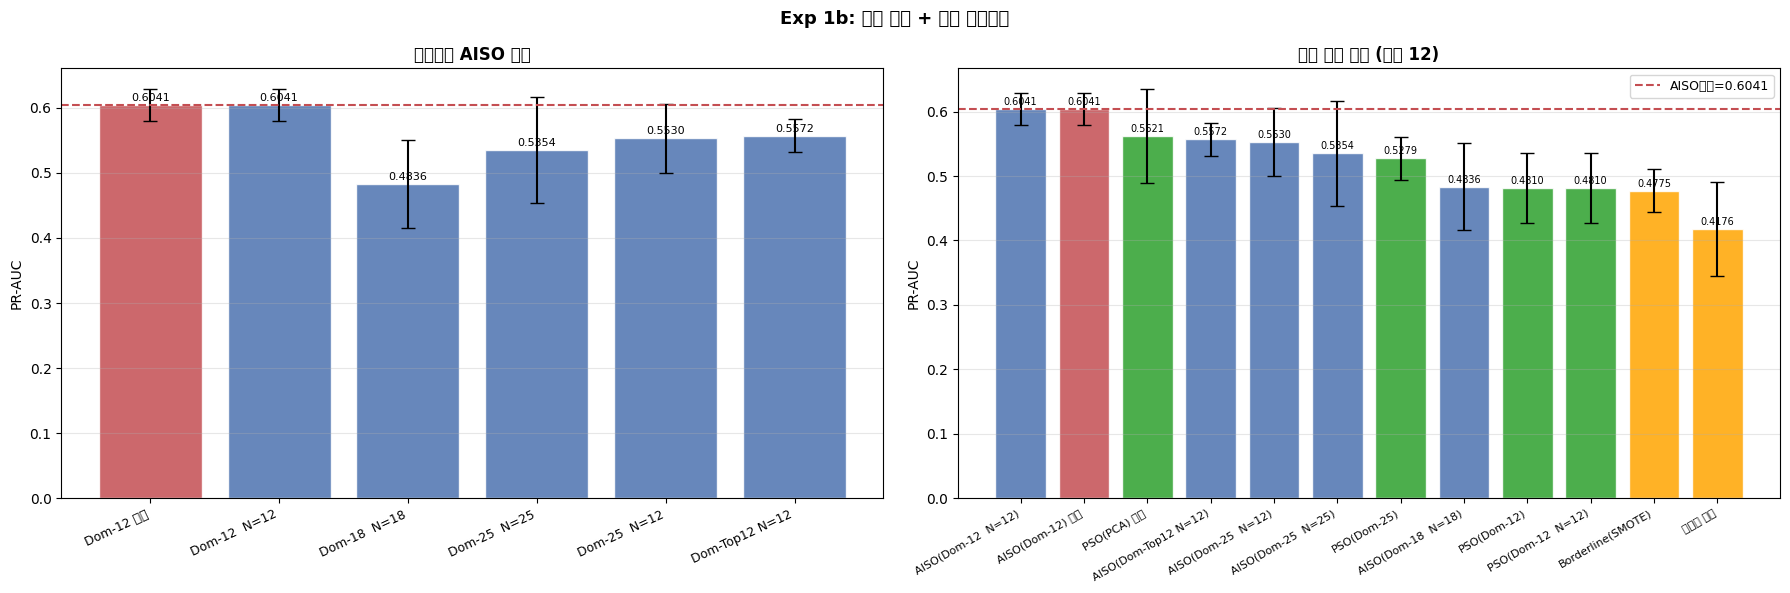

: 

In [ ]:
# ---- 최종 종합 비교 ----
all_methods = {}
all_methods['AISO(Dom-12) 기준'] = ([BASELINE_12]*5, BASELINE_12, BASELINE_STD)
for label, (scores, m, s, _, _) in feat_results.items():
    all_methods[f'AISO({label.strip()})'] = (scores, m, s)
for label, scores in pso_results.items():
    all_methods[label] = (scores, np.mean(scores), np.std(scores))
for label, scores in graph_results.items():
    all_methods[label] = (scores, np.mean(scores), np.std(scores))
all_methods['PSO(PCA) 기존'] = ([BASELINE_PSO_PCA]*5, BASELINE_PSO_PCA, 0.0732)

sorted_methods = sorted(all_methods.items(), key=lambda x: x[1][1], reverse=True)

print('=' * 68)
print('최종 종합 비교')
print('=' * 68)
print(f'{"방법":<30} {"mean":>7} {"std":>7}  vs AISO기준')
print('-' * 68)
for label, (scores, m, s) in sorted_methods:
    diff = m - BASELINE_12
    flag = '★' if m > BASELINE_12 and '기준' not in label else ''
    print(f'  {label:<28} {m:.4f}  {s:.4f}  {diff:+.4f} {flag}')
print('=' * 68)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 피처셋별 AISO 성능
ax = axes[0]
feat_labels = [k.replace('AISO(','').replace(')','') for k in all_methods if 'AISO' in k]
feat_means  = [all_methods[k][1] for k in all_methods if 'AISO' in k]
feat_stds   = [all_methods[k][2] for k in all_methods if 'AISO' in k]
clrs = ['#C44E52' if '기준' in l else '#4C72B0' for l in feat_labels]
bars = ax.bar(range(len(feat_labels)), feat_means, yerr=feat_stds,
              capsize=5, color=clrs, alpha=0.85, edgecolor='white')
ax.axhline(BASELINE_12, color='#C44E52', ls='--', lw=1.5)
ax.set_xticks(range(len(feat_labels)))
ax.set_xticklabels(feat_labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('PR-AUC'); ax.set_title('피처셋별 AISO 성능', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar, m in zip(bars, feat_means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.003, f'{m:.4f}',
            ha='center', va='bottom', fontsize=8)

# 오른쪽: 전체 방법 비교 (상위 12)
ax = axes[1]
top12 = sorted_methods[:12]
lbls2 = [l for l,_ in top12]
ms2   = [v[1] for _,v in top12]
ss2   = [v[2] for _,v in top12]
clrs2 = ['#C44E52' if '기준' in l else
         '#4C72B0' if 'AISO' in l else
         '#2ca02c' if 'PSO' in l else
         'orange' for l in lbls2]
bars2 = ax.bar(range(len(lbls2)), ms2, yerr=ss2,
               capsize=5, color=clrs2, alpha=0.85, edgecolor='white')
ax.axhline(BASELINE_12, color='#C44E52', ls='--', lw=1.5, label=f'AISO기준={BASELINE_12:.4f}')
ax.set_xticks(range(len(lbls2)))
ax.set_xticklabels(lbls2, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('PR-AUC'); ax.set_title('전체 방법 비교 (상위 12)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
for bar, m in zip(bars2, ms2):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.003, f'{m:.4f}',
            ha='center', va='bottom', fontsize=7)

plt.suptitle('Exp 1b: 피처 확장 + 공정 벤치마크', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('exp1b_final.png', bbox_inches='tight', dpi=120)
plt.show()